# CNN Baseline - Respiratory Disease Detection

Architecture simple CNN sur spectrogrammes Mel. Sert de baseline. 

In [48]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import librosa

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

SR, N_MELS, N_FFT, HOP_LENGTH = 22050, 128, 2048, 512

def compute_mel_spectrogram(audio):
    mel = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    return librosa.power_to_db(mel, ref=np.max)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE} | Seed : {SEED}')

Device : cuda | Seed : 42


## Chargement des données

In [49]:
PROCESSED_DIR = '../data/processed'
MODELS_DIR    = '../models'

X_mel = np.load(f'{PROCESSED_DIR}/X_mel.npy')  # (1208, 128, 259)
y_raw = np.load(f'{PROCESSED_DIR}/y.npy')       # (1208,) strings

le = LabelEncoder()
y  = le.fit_transform(y_raw)
CLASSES   = list(le.classes_)
N_CLASSES = len(CLASSES)

print(f'X_mel   : {X_mel.shape}')
print(f'Classes : {CLASSES}')
print(f'Distribution : { {c: int((y == i).sum()) for i, c in enumerate(CLASSES)} }')

X_mel   : (1208, 128, 259)
Classes : [np.str_('asthma'), np.str_('bronchial'), np.str_('copd'), np.str_('healthy'), np.str_('pneumonia')]
Distribution : {np.str_('asthma'): 285, np.str_('bronchial'): 104, np.str_('copd'): 401, np.str_('healthy'): 133, np.str_('pneumonia'): 285}


## Split stratifié 70 / 15 / 15

In [50]:
# 70 / 30
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(sss1.split(X_mel, y))

# 30 → 15 val + 15 test
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx, test_idx = next(sss2.split(X_mel[temp_idx], y[temp_idx]))
val_idx  = temp_idx[val_idx]
test_idx = temp_idx[test_idx]

X_train, y_train = X_mel[train_idx], y[train_idx]
X_val,   y_val   = X_mel[val_idx],   y[val_idx]
X_test,  y_test  = X_mel[test_idx],  y[test_idx]

print(f'Train : {X_train.shape[0]} | Val : {X_val.shape[0]} | Test : {X_test.shape[0]}')

Train : 845 | Val : 181 | Test : 182


In [51]:
for split_name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    total = len(y_split)
    dist  = {CLASSES[i]: f'{int((y_split==i).sum())} ({100*(y_split==i).mean():.1f}%)' for i in range(N_CLASSES)}
    print(f'{split_name:5s} ({total}) : {dist}')

Train (845) : {np.str_('asthma'): '199 (23.6%)', np.str_('bronchial'): '73 (8.6%)', np.str_('copd'): '281 (33.3%)', np.str_('healthy'): '93 (11.0%)', np.str_('pneumonia'): '199 (23.6%)'}
Val   (181) : {np.str_('asthma'): '43 (23.8%)', np.str_('bronchial'): '15 (8.3%)', np.str_('copd'): '60 (33.1%)', np.str_('healthy'): '20 (11.0%)', np.str_('pneumonia'): '43 (23.8%)'}
Test  (182) : {np.str_('asthma'): '43 (23.6%)', np.str_('bronchial'): '16 (8.8%)', np.str_('copd'): '60 (33.0%)', np.str_('healthy'): '20 (11.0%)', np.str_('pneumonia'): '43 (23.6%)'}


## Dataset & DataLoader

In [ ]:
class MelDataset(Dataset):
    def __init__(self, X, y):
        X = X.astype(np.float32)
        X = (X - X.min(axis=(1,2), keepdims=True)) / \
            (X.max(axis=(1,2), keepdims=True) - X.min(axis=(1,2), keepdims=True) + 1e-8)
        self.X = torch.tensor(X).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE   = 32
train_loader = DataLoader(MelDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(MelDataset(X_val,   y_val),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(MelDataset(X_test,  y_test),  batch_size=BATCH_SIZE)

print(f'Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

## Architecture CNN Baseline

4 blocs Conv2d → BatchNorm → ReLU → MaxPool + classifieur dense avec Dropout.

In [53]:
class CNNBaseline(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,   32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,  64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, n_classes)
        )

    def forward(self, x): return self.classifier(self.features(x))


model = CNNBaseline(n_classes=N_CLASSES).to(DEVICE)
print(f'Paramètres : {sum(p.numel() for p in model.parameters()):,}')

Paramètres : 2,489,029


## Entraînement avec class weights + early stopping

In [54]:
counts  = np.bincount(y_train)
weights = torch.tensor(1.0 / counts, dtype=torch.float32).to(DEVICE)
weights = weights / weights.sum() * N_CLASSES

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

NUM_EPOCHS   = 100
PATIENCE     = 15
best_val_f1  = 0.0
patience_cnt = 0
history      = {'train_loss': [], 'val_loss': [], 'val_f1': []}

for epoch in range(NUM_EPOCHS):
    # Train
    model.train()
    train_loss = 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Val
    model.eval()
    val_loss, preds, targets = 0, [], []
    with torch.no_grad():
        for X_b, y_b in val_loader:
            out = model(X_b.to(DEVICE))
            val_loss += criterion(out, y_b.to(DEVICE)).item()
            preds.extend(out.argmax(1).cpu().numpy())
            targets.extend(y_b.numpy())

    val_f1 = f1_score(targets, preds, average='macro')
    scheduler.step(val_loss)
    history['train_loss'].append(train_loss / len(train_loader))
    history['val_loss'].append(val_loss   / len(val_loader))
    history['val_f1'].append(val_f1)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:03d}/{NUM_EPOCHS}  train={train_loss/len(train_loader):.4f}  val={val_loss/len(val_loader):.4f}  F1={val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), f'{MODELS_DIR}/cnn_best.pth')
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'Early stopping epoch {epoch+1}')
            break

print(f'\nMeilleur val F1-macro : {best_val_f1:.4f}')

Epoch 010/100  train=1.0776  val=1.3771  F1=0.3683
Epoch 020/100  train=0.9389  val=1.2740  F1=0.5218
Epoch 030/100  train=0.6910  val=0.9988  F1=0.6163
Epoch 040/100  train=0.5045  val=1.0737  F1=0.6606
Epoch 050/100  train=0.3999  val=1.0442  F1=0.6745
Early stopping epoch 53

Meilleur val F1-macro : 0.7111


## Courbes d'apprentissage

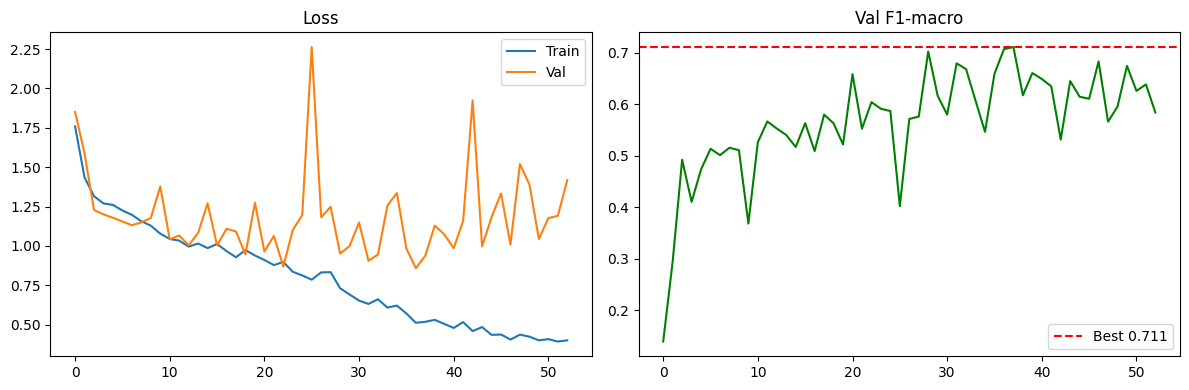

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history['val_f1'], color='green')
axes[1].axhline(best_val_f1, color='red', linestyle='--', label=f'Best {best_val_f1:.3f}')
axes[1].set_title('Val F1-macro'); axes[1].legend()
plt.tight_layout(); plt.show()

## Évaluation sur le Test set

=== CNN Baseline — Test set ===
              precision    recall  f1-score   support

      asthma       0.90      0.86      0.88        43
   bronchial       1.00      0.62      0.77        16
        copd       0.72      1.00      0.84        60
     healthy       0.79      0.75      0.77        20
   pneumonia       0.93      0.63      0.75        43

    accuracy                           0.82       182
   macro avg       0.87      0.77      0.80       182
weighted avg       0.85      0.82      0.81       182

F1-macro : 0.8017
AUC-ROC  : 0.9683


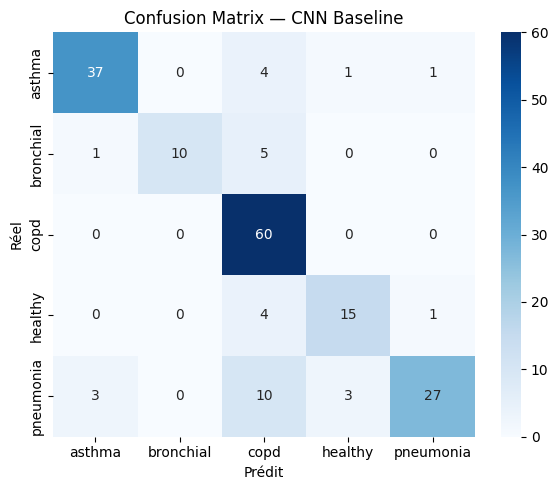

In [56]:
model.load_state_dict(torch.load(f'{MODELS_DIR}/cnn_best.pth', map_location=DEVICE))
model.eval()

all_preds, all_targets, all_probs = [], [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        out   = model(X_b.to(DEVICE))
        probs = F.softmax(out, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_targets.extend(y_b.numpy())

all_probs = np.array(all_probs)

print('=== CNN Baseline — Test set ===')
print(classification_report(all_targets, all_preds, target_names=CLASSES))
print(f'F1-macro : {f1_score(all_targets, all_preds, average="macro"):.4f}')
print(f'AUC-ROC  : {roc_auc_score(np.eye(N_CLASSES)[all_targets], all_probs, multi_class="ovr", average="macro"):.4f}')

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.title('Confusion Matrix — CNN Baseline')
plt.ylabel('Réel'); plt.xlabel('Prédit')
plt.tight_layout(); plt.show()